# 10｜正則化與機率分類

對應 `05_正則化與機率分類.md`（主教材 Ch.4 pp.159–178）。課堂操作約 25 分鐘。目標：說明正則化如何改變訓練目標、sigmoid／softmax 如何把分數轉成機率、機率如何再轉成決策。

## 來源與改編界線
- [ageron/handson-mlp / 04_training_linear_models.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/04_training_linear_models.ipynb)：Ridge/Lasso/Elastic Net、Early Stopping、Logistic Regression、Softmax Regression 各節
- [leonjyentub/MachineLearning2025 / 02_Regularization_Regression.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/02_Regularization_Regression.ipynb)：PolynomialFeatures + StandardScaler + Ridge／Lasso
- [leonjyentub/MachineLearning2025 / 01_Logistic_Regression_scratch_Iris1.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/01_Logistic_Regression_scratch_Iris1.ipynb)：手寫 sigmoid 與交叉熵梯度下降

**本課程修改／補充：** 在 12 次多項式上比較 OLS／Ridge／Lasso／ElasticNet 的係數路徑與稀疏度；明示 sklearn `ElasticNet` 目標函數與教材式 4-13 的樣本數係數不同，同一個 alpha 不可互比。手寫 logistic 用 `expit`／`logaddexp` 保持數值穩定、梯度為 $X^\top(\hat p-y)/m$；softmax 先減最大分數。加入投影片三個手算活動（懲罰、閾值、softmax 數例）的驗算，並以 Pipeline + `GridSearchCV` 選 `C`。早停完整迴圈見 Notebook 02。

來源固定至上述 commit；原檔保留於 `../upstream/`，逐檔 SHA-256 見 `../upstream/manifest.json`。Géron 程式依 Apache-2.0 改編，授權原文保留；教師程式保留原作者歸屬。儲存格索引從 0 起算。圖表與數值是本 Notebook 重跑結果，不能直接當成書中成效。

從第一格依序執行；各本可獨立重跑。Python 環境與資料準備見 [操作說明](../README.md)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. Ridge、Lasso、Elastic Net 的係數路徑

同一份 12 次多項式特徵，改變正則化。L1 可把部分係數壓成 0；L2 連續縮小。不同 API 的 alpha 尺度不同，數值不可直接互比。

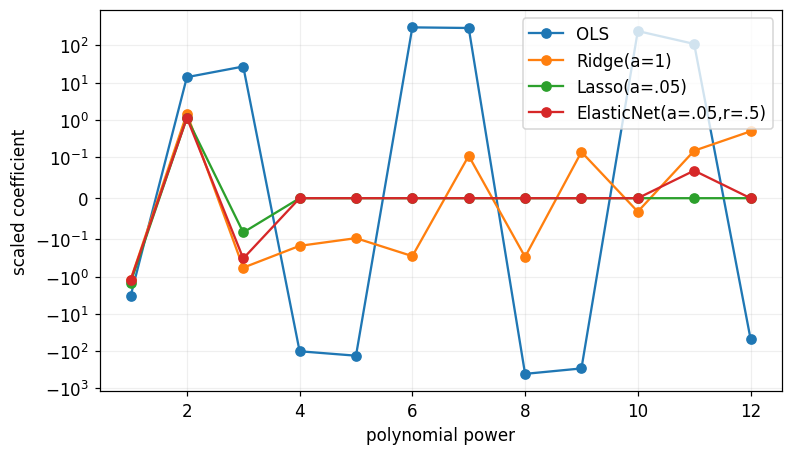

,CV_RMSE,L2_norm,zero_coefs
model,,,
OLS,2.224699,736.944550,0
Ridge(a=1),2.119559,2.115135,0
Lasso(a=.05),2.085835,1.840726,9
"ElasticNet(a=.05,r=.5)",2.093590,1.726003,8


In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error

rng = np.random.default_rng(SEED)
x = rng.uniform(-3, 3, size=(160, 1))
y = 0.5 * x[:, 0] ** 2 - x[:, 0] + 2 + rng.normal(0, 2, 160)
folds = list(KFold(5, shuffle=True, random_state=SEED).split(x))

def poly(est):
    return make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler(), est)

models = {'OLS': LinearRegression(), 'Ridge(a=1)': Ridge(alpha=1.0),
          'Lasso(a=.05)': Lasso(alpha=.05, max_iter=100000),
          'ElasticNet(a=.05,r=.5)': ElasticNet(alpha=.05, l1_ratio=.5, max_iter=100000)}
rows = []
for name, est in models.items():
    pipe = poly(est).fit(x, y)
    coef = pipe[-1].coef_
    cv = -cross_val_score(poly(est), x, y, cv=folds, scoring='neg_root_mean_squared_error').mean()
    rows.append({'model': name, 'CV_RMSE': cv, 'L2_norm': np.linalg.norm(coef),
                 'zero_coefs': int(np.sum(np.abs(coef) < 1e-8))})
    plt.plot(np.arange(1, 13), coef, 'o-', label=name)
plt.yscale('symlog', linthresh=.1); plt.xlabel('polynomial power'); plt.ylabel('scaled coefficient'); plt.legend()
savefig('10_regularization_paths')
reg_table = pd.DataFrame(rows).set_index('model')
assert reg_table.loc['Lasso(a=.05)', 'zero_coefs'] > 0 and reg_table.loc['Ridge(a=1)', 'zero_coefs'] == 0
reg_table

In [3]:
# 同叫 alpha，目標函數尺度不同：教材式 4-13 的 L2 項帶 1/m，sklearn ElasticNet 不帶。
m = len(x)
Zp = make_pipeline(PolynomialFeatures(12, include_bias=False), StandardScaler()).fit_transform(x)
w = ElasticNet(alpha=.05, l1_ratio=.5, max_iter=100000).fit(Zp, y).coef_
mse = np.mean((Zp @ w + y.mean() - y) ** 2)   # 近似資料項
book_obj = mse + 2 * .5 * .05 * np.abs(w).sum() + (1 - .5) * .05 / m * np.sum(w ** 2)
sklearn_obj = mse / 2 + .05 * .5 * np.abs(w).sum() + .05 * (1 - .5) / 2 * np.sum(w ** 2)
print('教材式 4-13 目標 ≈', round(book_obj, 4), ' | sklearn ElasticNet 目標 ≈', round(sklearn_obj, 4))
print('兩者不相等；跨 API 不能沿用同一個 alpha。')

教材式 4-13 目標 ≈ 4.1378  | sklearn ElasticNet 目標 ≈ 2.1059
兩者不相等；跨 API 不能沿用同一個 alpha。


## 2. 手算驗算：哪組參數的懲罰代價大？

對應投影片活動「手算懲罰」。$w_A=(2,0)$、$w_B=(1,1)$，資料誤差相同。

In [4]:
wA, wB = np.array([2., 0.]), np.array([1., 1.])
pen = pd.DataFrame({'L1_norm': [np.abs(wA).sum(), np.abs(wB).sum()],
                    'L2_norm_squared': [np.sum(wA ** 2), np.sum(wB ** 2)]},
                   index=['w_A = (2, 0)', 'w_B = (1, 1)'])
assert pen.L1_norm.tolist() == [2., 2.]                 # L1 相同
assert pen.L2_norm_squared.tolist() == [4., 2.]         # Ridge 偏好 w_B
pen

,L1_norm,L2_norm_squared
"w_A = (2, 0)",2.0,4.0
"w_B = (1, 1)",2.0,2.0


## 3. 手寫 logistic 迴歸：分數 → 機率 → 決策

以 Iris virginica 為正類、花瓣寬度為單一特徵（教材圖 4-24）。用 `expit` 與 `logaddexp` 保持數值穩定；梯度 $\nabla J = \frac1m X^\top(\hat p - y)$，沒有 MSE 的係數 2。

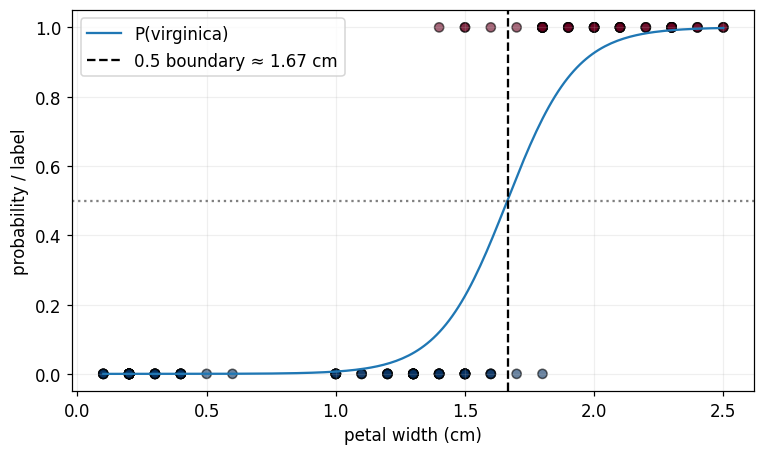

final training loss: 0.1121  decision boundary: 1.668 cm


In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from scipy.special import expit
iris = load_iris()
Xpw = iris.data[:, 3:4]                       # 花瓣寬度
y_vir = (iris.target == 2).astype(float)      # virginica = 正類
Xtr, Xte, ytr, yte = train_test_split(Xpw, y_vir, test_size=.3, stratify=y_vir, random_state=SEED)
mu, sd = Xtr.mean(), Xtr.std()
Ztr, Zte = (Xtr - mu) / sd, (Xte - mu) / sd

def fit_logistic(Z, y, eta=.3, epochs=800):
    w, b, loss = 0.0, 0.0, []
    for _ in range(epochs):
        z = Z[:, 0] * w + b
        p = expit(z)
        loss.append(np.mean(np.logaddexp(0, z) - y * z))       # 穩定的平均交叉熵
        g = p - y
        w -= eta * np.mean(g * Z[:, 0]); b -= eta * np.mean(g)
    return w, b, np.array(loss)

w, b, loss = fit_logistic(Ztr, ytr)
grid = np.linspace(Xpw.min(), Xpw.max(), 200)
prob = expit(((grid - mu) / sd) * w + b)
boundary = grid[np.argmin(np.abs(prob - 0.5))]
plt.plot(grid, prob, label='P(virginica)')
plt.axhline(.5, ls=':', c='grey'); plt.axvline(boundary, ls='--', c='k', label=f'0.5 boundary ≈ {boundary:.2f} cm')
plt.scatter(Xpw[:, 0], y_vir, c=y_vir, cmap='RdBu_r', edgecolor='k', alpha=.6)
plt.xlabel('petal width (cm)'); plt.ylabel('probability / label'); plt.legend()
savefig('10_logistic_probability')
assert np.all(np.diff(loss) <= 1e-9)          # 交叉熵單調下降
assert 1.4 < boundary < 1.9
print('final training loss:', round(loss[-1], 4), ' decision boundary:', round(boundary, 3), 'cm')

## 4. 手算驗算：機率不是最後決策

對應投影片活動「比較兩個閾值」。真值 `[1,0,1,0]`、正類機率 `[.8,.6,.4,.1]`。

In [6]:
probs = np.array([.8, .6, .4, .1]); truth = np.array([1, 0, 1, 0])
def counts(t):
    pred = probs >= t
    tp = int(np.sum(pred & (truth == 1))); fp = int(np.sum(pred & (truth == 0)))
    fn = int(np.sum(~pred & (truth == 1))); tn = int(np.sum(~pred & (truth == 0)))
    return {'threshold': t, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn}
thr = pd.DataFrame([counts(.5), counts(.3)])
assert thr[['TP', 'FP', 'FN', 'TN']].values.tolist() == [[1, 1, 1, 1], [2, 1, 0, 1]]
thr

,threshold,TP,FP,FN,TN
0,0.5,1,1,1,1
1,0.3,2,1,0,1


## 5. 兩個特徵的線性決策邊界

logistic 對原始特徵的分數是線性的，決策邊界是直線（教材圖 4-25）。加入非線性特徵才會彎曲。

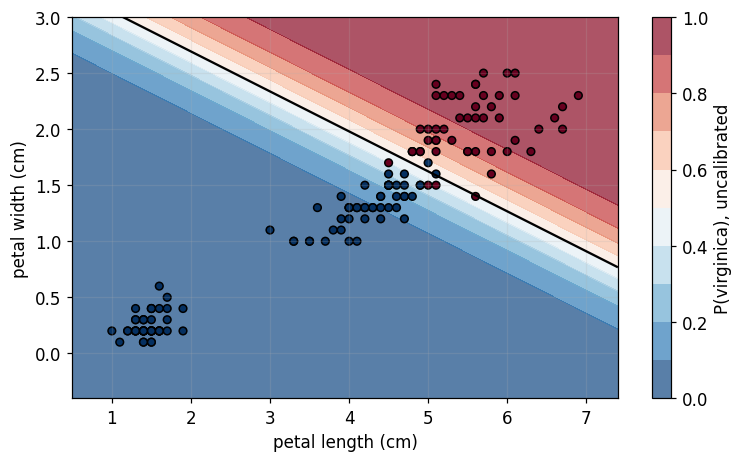

In [7]:
from sklearn.linear_model import LogisticRegression
X2 = iris.data[:, 2:4]                        # 花瓣長、寬
lr2 = make_pipeline(StandardScaler(), LogisticRegression()).fit(X2, y_vir)
xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - .5, X2[:, 0].max() + .5, 200),
                     np.linspace(X2[:, 1].min() - .5, X2[:, 1].max() + .5, 200))
zz = lr2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
plt.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap='RdBu_r', alpha=.7)
plt.colorbar(label='P(virginica), uncalibrated')
plt.contour(xx, yy, zz, levels=[.5], colors='k')
plt.scatter(X2[:, 0], X2[:, 1], c=y_vir, cmap='RdBu_r', edgecolor='k', s=25)
plt.xlabel('petal length (cm)'); plt.ylabel('petal width (cm)')
savefig('10_logistic_boundary_2d')

## 6. 手寫穩定 softmax 與多類別交叉熵

softmax 對所有分數加同一常數不變，因此先減最大分數避免溢位。搭配交叉熵時梯度簡化為 $\hat p - y$。

softmax([0,1,2]) = [0.09003 0.24473 0.66524]  | class-2 loss = 0.40761


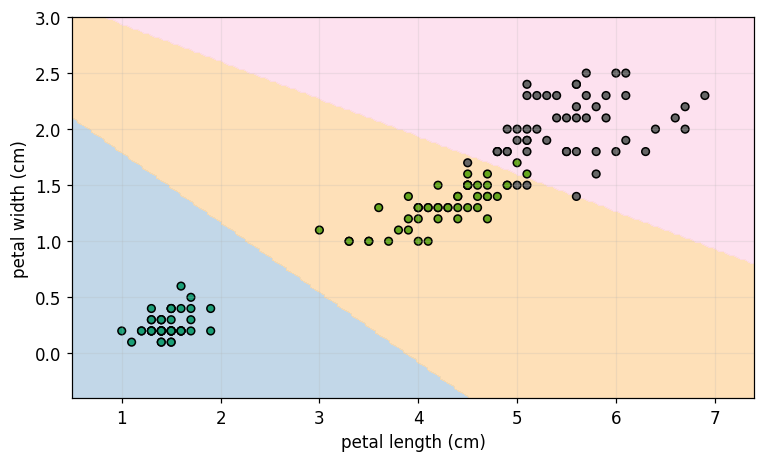

hand-written softmax regression training accuracy: 0.953


In [8]:
def softmax(s):
    s = np.asarray(s, float)
    e = np.exp(s - s.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

assert np.allclose(softmax([1000, 1001, 1002]), softmax([-2, -1, 0]))     # 平移不變
demo = softmax([0, 1, 2])
assert np.allclose(demo, [0.09003057, 0.24472847, 0.66524096], atol=1e-6)
assert np.isclose(-np.log(demo[2]), 0.40760596, atol=1e-6)                # 類別 2 的損失
print('softmax([0,1,2]) =', np.round(demo, 5), ' | class-2 loss =', round(float(-np.log(demo[2])), 5))

# 三類 Iris：softmax 迴歸的決策區域（教材圖 4-26），用兩個花瓣特徵
Xs = StandardScaler().fit_transform(iris.data[:, 2:4]); ys = iris.target
W = np.zeros((3, 3))                          # 3 類 × (bias + 2 特徵)
Xa = np.c_[np.ones(len(Xs)), Xs]
Y = np.eye(3)[ys]
for _ in range(4000):
    P = softmax(Xa @ W.T)
    W -= 0.1 * ((P - Y).T @ Xa) / len(Xa)
pred = np.argmax(Xa @ W.T, axis=1)
zz = np.argmax(np.c_[np.ones(xx.size), ((np.c_[xx.ravel(), yy.ravel()] - iris.data[:, 2:4].mean(0)) /
     iris.data[:, 2:4].std(0))] @ W.T, axis=1).reshape(xx.shape)
plt.contourf(xx, yy, zz, levels=[-.5, .5, 1.5, 2.5], cmap='Pastel1', alpha=.8)
plt.scatter(iris.data[:, 2], iris.data[:, 3], c=ys, cmap='Dark2', edgecolor='k', s=25)
plt.xlabel('petal length (cm)'); plt.ylabel('petal width (cm)')
savefig('10_softmax_regions')
print('hand-written softmax regression training accuracy:', round(float(np.mean(pred == ys)), 3))

## 7. 用 Pipeline 選正則化強度 C

`C` 越小正則化越強。標準化放進 Pipeline，`GridSearchCV` 每折重新 fit；選定後才看一次測試。

In [9]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, log_loss
Xtr, Xte, ytr, yte = train_test_split(iris.data, iris.target, test_size=.3, stratify=iris.target, random_state=SEED)
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
search = GridSearchCV(pipe, {'logisticregression__C': [0.01, 0.1, 1, 10]}, cv=5).fit(Xtr, ytr)
final = search.best_estimator_
proba = final.predict_proba(Xte)
metrics = {'best_C': search.best_params_['logisticregression__C'],
           'CV_accuracy': float(search.best_score_),
           'test_accuracy': float(final.score(Xte, yte)),
           'test_log_loss': float(log_loss(yte, proba)),
           'test_confusion_matrix': confusion_matrix(yte, final.predict(Xte)).tolist(),
           'softmax_demo': demo.tolist(), 'softmax_class2_loss': float(-np.log(demo[2]))}
report('regularization_classification', metrics)
pd.Series(metrics)

best_C                                                                   1
CV_accuracy                                                       0.980952
test_accuracy                                                     0.911111
test_log_loss                                                     0.209597
test_confusion_matrix                 [[15, 0, 0], [0, 14, 1], [0, 3, 12]]
softmax_demo             [0.09003057317038046, 0.24472847105479764, 0.6...
softmax_class2_loss                                               0.407606
dtype: object

## 練習與參考答案

- 係數變小代表特徵沒有因果作用嗎？**否，只表示在此正則化與尺度下權重被壓縮。**
- 驗證集選過 `C` 或早停後還能當測試集嗎？**不能，它已參與模型選擇。**
- softmax 機率加總為 1 代表已校準嗎？**否，加總為 1 是定義，校準要另外檢查。**
- 早停的完整「監看、耐心、保存、回復」迴圈見 Notebook 02 第 3 節。